[5090.202, 5101.666, 5053.748, 5083.42, 5080.606, 4996.086, 5009.991, 5045.447, 4989.075, 5039.635, 4993.007, 5042.635, 5001.125, 5015.802, 5078.377, 5034.885, 5069.137, 4985.82, 5046.978, 5035.31, 5031.234, 4968.795, 5030.596, 4999.653, 4997.388, 4954.122, 5013.297, 4995.867, 5048.116, 5018.941, 5005.539, 5040.411, 5024.667, 5001.263, 5005.875, 4981.666, 5009.219, 5069.89, 4996.062, 5021.229]


(array([2., 1., 7., 7., 5., 7., 4., 2., 3., 2.]),
 array([4954.122 , 4968.8764, 4983.6308, 4998.3852, 5013.1396, 5027.894 ,
        5042.6484, 5057.4028, 5072.1572, 5086.9116, 5101.666 ]),
 <BarContainer object of 10 artists>)

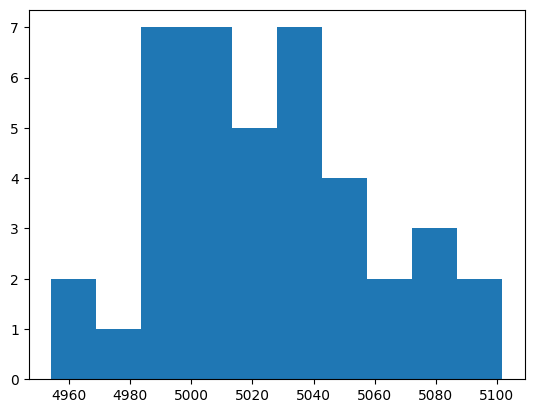

In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math


prefix = "../results/"
instance = "pg_duckdb_parquet"
postfix = "_03_select.dat"
f = prefix + instance + postfix

t = []
with open(f, 'r') as file:
    for line in file:
        clear = line.strip()
        if clear:
            clear_dot = clear.replace(',', '.')
            t.append(float(clear_dot))
print(t)
plt.hist(t)

In [2]:
test_normal = stats.normaltest(t)
test_shapiro = stats.shapiro(t)
# print(test_normal, test_shapiro, sep = '\n')
print("Тест на нормальность данных: ", end='')
if test_normal[1] > 0.05 or test_shapiro[1] > 0.05:
    print("ПРОЙДЕН")
else:
    print("НЕ ПРОЙДЕН")

Тест на нормальность данных: ПРОЙДЕН


In [3]:
mean = np.mean(t)
std = np.std(t, ddof=1)
quality = (std / mean) * 100
print(f"Среднее: {mean}\nСтандартное отклонение: {std}\nОтношение std/mean (%): {quality}")

Среднее: 5025.1695500000005
Стандартное отклонение: 34.79076529914228
Отношение std/mean (%): 0.6923301781756254


In [4]:
interval = stats.t.ppf(0.975, df=len(t)-1)*stats.sem(t)
print(f"Доверительный интервал: {interval}")

Доверительный интервал: 11.126626538537117


### Округление
- Погрешность: 11 (мс)
- Среднее: 5025 (мс)
### Итог
- Результирующее значение: 5025 ± 11 (мс)